In [3]:
import sys
from tqdm import tqdm 
import numpy as np
from skimage.transform import resize
from numpy.fft import fftn, fftshift
import matplotlib.pyplot as plt
import os
from matplotlib import colors
import matplotlib.pyplot as plt
import random
from multiprocessing import Pool, get_context
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor
from joblib import Parallel, delayed
from pathlib import Path
import h5py
import torch

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../')))
from src.utils.preprocessing_functions import *
plt.rcParams["image.cmap"] = "jet"

In [4]:
#reduce size of diffraction patterns
red=False #True

#save processed data
save=False

# Setting path
# path = Path("Y:/ptychosaxs")  # /net/micdata/data2/12IDC mounted windows drive
path = Path("/net/micdata/data2/12IDC/ptychosaxs")  # on remote server
print(path)

/net/micdata/data2/12IDC/ptychosaxs


In [5]:
# # Parameters
# num = 'ZC4'  # Dataset number
# max_dps = 10800  # Maximum number of diffraction patterns to include

# # Define the base path
# base_path = Path('/net/micdata/data2/12IDC/ptychosaxs')
# data_location = base_path / f'data/diff_sim/{num}/'
# print(f"Reading data from: {data_location}")

# # Generate the specific filenames with the required pattern
# filenames = []
# for numdps in range(1, max_dps + 1):
#     filename = f"output_hanning_conv_{numdps:05d}.npz"
#     file_path = data_location / filename
#     if file_path.exists():
#         filenames.append(file_path)
#     else:
#         # Stop if we can't find the next file (optional)
#         # break
#         pass

# print(f"Found {len(filenames)} files matching the pattern")

# # Combine into HDF5 (if not already done so)
# output_file = base_path / f"data/combined_data_{num}.h5"
# if output_file.exists():
#     print(f'Combined file {output_file} already exists')
# else:
#     print('Loading and writing to h5...')
#     with h5py.File(output_file, "w") as h5f:
#         for i, file_path in tqdm(enumerate(filenames)):
#             data = np.load(file_path)
#             h5f.create_dataset(f"convDP_{i}", data=data["convDP"])
#             h5f.create_dataset(f"pinholeDP_{i}", data=data["pinholeDP"])
#             h5f.create_dataset(f"pinholeDP_extra_conv_{i}", data=data["pinholeDP_extra_conv"])
    
#     print(f"Successfully created {output_file} with {len(filenames)} diffraction patterns")


# Parameters
num = 'DELETE'  # Dataset number
max_dps = 9000  # Maximum number of diffraction patterns to include

# Define the base path
base_path = Path('/net/micdata/data2/12IDC/ptychosaxs')
data_location = base_path / f'data/diff_sim/{num}/'
print(f"Reading data from: {data_location}")

# Generate the specific filenames with the required pattern
filenames = []
for numdps in range(1, max_dps + 1):
    filename = f"output_hanning_conv_{numdps:05d}.npz"
    file_path = data_location / filename
    if file_path.exists():
        filenames.append(file_path)
    else:
        pass

print(f"Found {len(filenames)} files matching the pattern")

def process_batch(batch_files):
    """Process a batch of files and return their data"""
    batch_data = []
    for file_path in batch_files:
        data = np.load(file_path)
        batch_data.append({
            'convDP': data['convDP'],
            'pinholeDP': data['pinholeDP'],
            'pinholeDP_extra_conv': data['pinholeDP_extra_conv'],
            'convDP_pinhole': data['convDP_pinhole']
        })
    return batch_data

def write_batch_to_h5(batch_data, h5f, start_idx):
    """Write a batch of data to HDF5 file"""
    for i, data in enumerate(batch_data):
        idx = start_idx + i
        h5f.create_dataset(f"convDP_{idx}", data=data['convDP'], 
                          compression='gzip', compression_opts=4)
        h5f.create_dataset(f"pinholeDP_{idx}", data=data['pinholeDP'],
                          compression='gzip', compression_opts=4)
        h5f.create_dataset(f"pinholeDP_extra_conv_{idx}", data=data['pinholeDP_extra_conv'],
                          compression='gzip', compression_opts=4)
        h5f.create_dataset(f"convDP_pinhole_{idx}", data=data['convDP_pinhole'],
                          compression='gzip', compression_opts=4)

# Combine into HDF5 (if not already done so)
output_file = base_path / f"data/combined_data_{num}.h5"
if output_file.exists():
    print(f'Combined file {output_file} already exists')
else:
    print('Loading and writing to h5...')
    
    # Configure parallel processing
    num_cores = os.cpu_count() - 1  # Leave one core free
    batch_size = 100  # Process 100 files at a time
    
    with h5py.File(output_file, "w") as h5f:
        # Process files in batches
        for batch_start in tqdm(range(0, len(filenames), batch_size)):
            batch_end = min(batch_start + batch_size, len(filenames))
            batch_files = filenames[batch_start:batch_end]
            
            # Process batch in parallel
            with ProcessPoolExecutor(max_workers=num_cores) as executor:
                # Split batch into smaller chunks for parallel processing
                chunk_size = max(1, len(batch_files) // num_cores)
                chunks = [batch_files[i:i + chunk_size] for i in range(0, len(batch_files), chunk_size)]
                
                # Process chunks in parallel
                batch_results = list(executor.map(process_batch, chunks))
                
                # Flatten results
                batch_data = [item for sublist in batch_results for item in sublist]
                
                # Write batch to HDF5
                write_batch_to_h5(batch_data, h5f, batch_start)
    
    print(f"Successfully created {output_file} with {len(filenames)} diffraction patterns")

Reading data from: /net/micdata/data2/12IDC/ptychosaxs/data/diff_sim/DELETE
Found 9000 files matching the pattern
Combined file /net/micdata/data2/12IDC/ptychosaxs/data/combined_data_DELETE.h5 already exists


In [43]:
#load convoluted and ideal diffraction patterns
print('Loading data...')
# Load data with progress bar
with h5py.File(output_file, "r") as h5f:
    # Get the keys (dataset names)
    dataset_keys = list(h5f.keys()) 
    num_datasets = len(dataset_keys) //4 #// 2  # Assuming convDP and pinholeDP pairs
    print(f'{num_datasets} diffraction patterns')
    # Initialize empty lists for the data
    conv_DPs = []
    pinhole_DPs = []
    #conv_DPs_pinhole = []
    #pinhole_DPs_extra_conv = []
    # Number of diffration patterns
    numDPs = max_dps#10800#10000
    
    # Use tqdm for progress tracking
    for i in tqdm(range(num_datasets)[:numDPs], desc="Loading HDF5 datasets"):
        conv_DPs.append(h5f[f"convDP_{i}"][:])  # Load convDP dataset
        #conv_DPs.append(h5f[f"convDP_pinhole_{i}"][:])  # Load convDP_pinhole dataset
        pinhole_DPs.append(h5f[f"pinholeDP_{i}"][:])  # Load pinholeDP dataset
        #pinhole_DPs.append(h5f[f"pinholeDP_extra_conv_{i}"][:])  # Load pinholeDP_extra_conv dataset
        
# convert to np arrays
conv_DPs=np.asarray(conv_DPs)
ideal_DPs=np.asarray(pinhole_DPs)
probe_DPs=np.ones(conv_DPs.shape) #dummy array for testing network with a probe


Loading data...
9000 diffraction patterns


Loading HDF5 datasets: 100%|██████████| 9000/9000 [04:47<00:00, 31.26it/s]


In [78]:
#normalize ideal and conv DP by flooring to mean
conv_DPs_test_nothing=[]
ideal_DPs_test=[]
conv_DPs_test=[]
for i in range(len(ideal_DPs)):
    mean = np.mean(ideal_DPs[i])
    std = np.std(ideal_DPs[i])
    z = (ideal_DPs[i] - mean) / std
    #z_clipped = np.clip(z, 0, None)  # Only keep positive deviations
    ideal_DPs_test.append(z)
    
    mean = np.mean(conv_DPs[i])
    std = np.std(conv_DPs[i])
    z = (conv_DPs[i] - mean) / std
    #z_clipped = np.clip(z, 0, None)  # Only keep positive deviations
    conv_DPs_test.append(z)
    
    conv_DPs_test_nothing.append(conv_DPs[i])
    
# ideal_DPs_test=[np.maximum(np.mean(dp), dp-np.mean(dp)) for dp in pinhole_DPs]
# conv_DPs_test=[np.maximum(np.mean(dp), dp-np.mean(dp)) for dp in conv_DPs]
# conv_DPs_test_nothing=[dp for dp in conv_DPs]

5933


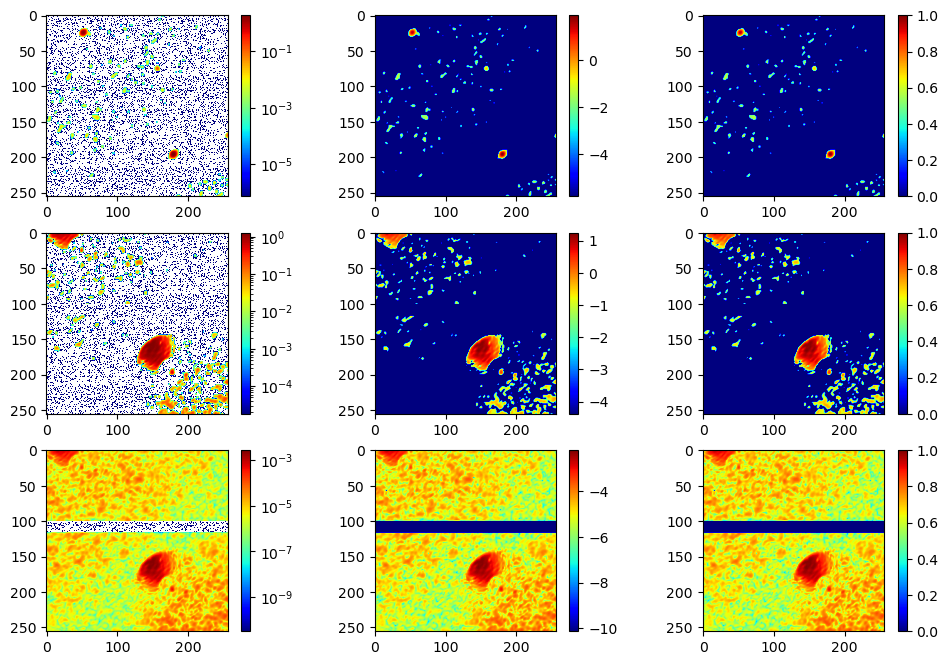

In [86]:
# TEST preprocessing
fig,ax=plt.subplots(3,3,figsize=(12,8))
ri=random.randint(0,len(pinhole_DPs)-1)
#ri=3825
print(ri)
im1=ax[0,0].imshow(np.log10(ideal_DPs_test[ri]+1), cmap='jet',norm=colors.LogNorm())
im2=ax[1,0].imshow(np.log10(conv_DPs_test[ri]+1), cmap='jet',norm=colors.LogNorm())
im3=ax[2,0].imshow(np.log10(conv_DPs_test_nothing[ri]+1), cmap='jet',norm=colors.LogNorm())
temp1=log10_custom(ideal_DPs_test[ri])
temp2=log10_custom(conv_DPs_test[ri])
temp3=log10_custom(conv_DPs_test_nothing[ri])
im4=ax[0,1].imshow(temp1, cmap='jet')
im5=ax[1,1].imshow(temp2, cmap='jet')
im6=ax[2,1].imshow(temp3, cmap='jet')
im7=ax[0,2].imshow((temp1-np.min(temp1))/(np.max(temp1)-np.min(temp1)), cmap='jet')
im8=ax[1,2].imshow((temp2-np.min(temp2))/(np.max(temp2)-np.min(temp2)), cmap='jet')
im9=ax[2,2].imshow((temp3-np.min(temp3))/(np.max(temp3)-np.min(temp3)), cmap='jet')
plt.colorbar(im1)
plt.colorbar(im2)
plt.colorbar(im3)
plt.colorbar(im4)
plt.colorbar(im5)
plt.colorbar(im6)
plt.colorbar(im7)
plt.colorbar(im8)
plt.colorbar(im9)
plt.show()

In [87]:
def create_circular_waxs_mask_min_value(image, radius):
    """
    Create a modified version of the image where the central region is set to the minimum value.
    
    Args:
        image (ndarray): Input image to be masked
        radius (int): Radius of the central circular region to modify
        
    Returns:
        ndarray: Image with central circle set to minimum value
    """
    # Create a copy of the image
    masked_image = image.copy()
    
    # Find minimum value in the image (excluding zeros or NaNs if needed)
    valid_pixels = image[image > 0]  # Adjust if needed
    if len(valid_pixels) > 0:
        min_val = np.min(valid_pixels)
    else:
        min_val = 0
    
    # Create the circular mask
    h, w = image.shape
    y, x = np.indices((h, w))
    center_y, center_x = h // 2, w // 2
    distance_from_center = np.sqrt((x - center_x) ** 2 + (y - center_y) ** 2)
    
    # Set central region to minimum value
    central_region = (distance_from_center <= radius)
    masked_image[central_region] = min_val
    
    return masked_image

# Load your detector mask as before
# detector_mask = ~np.load(os.path.abspath(os.path.join(os.getcwd(), '../../data/mask/mask_RC02_R3D_1280.npy')))

# Apply both masks to each image
processed_conv_DPs = []
processed_ideal_DPs = []

# Define the radius for the WAXS mask
radius = 88#64

apply_detector_mask=False
waxs_mask=False



# Process each image
for i in tqdm(range(len(conv_DPs_test))):
    if apply_detector_mask:
        # First apply the detector mask
        masked_conv = apply_mask(conv_DPs_test[i], np.ones(conv_DPs_test[i].shape))#~detector_mask)
        masked_ideal = apply_mask(ideal_DPs_test[i], np.ones(ideal_DPs_test[i].shape))#~detector_mask)
    else:
        masked_conv=conv_DPs_test[i]
        masked_ideal=ideal_DPs_test[i]
    #masked_ideal=ideal_DPs[i]

    
    if waxs_mask:
        # Then apply the WAXS mask that sets central region to minimum
        processed_conv = create_circular_waxs_mask_min_value(masked_conv, radius)
        processed_ideal = create_circular_waxs_mask_min_value(masked_ideal, radius)
        
        processed_conv_DPs.append(processed_conv)
        processed_ideal_DPs.append(processed_ideal)
    
    else:
        processed_conv_DPs.append(masked_conv)
        processed_ideal_DPs.append(masked_ideal)


# Convert to numpy arrays
processed_conv_DPs = np.array(processed_conv_DPs)
processed_ideal_DPs = np.array(processed_ideal_DPs)


100%|██████████| 9000/9000 [00:00<00:00, 2009087.02it/s]

4586


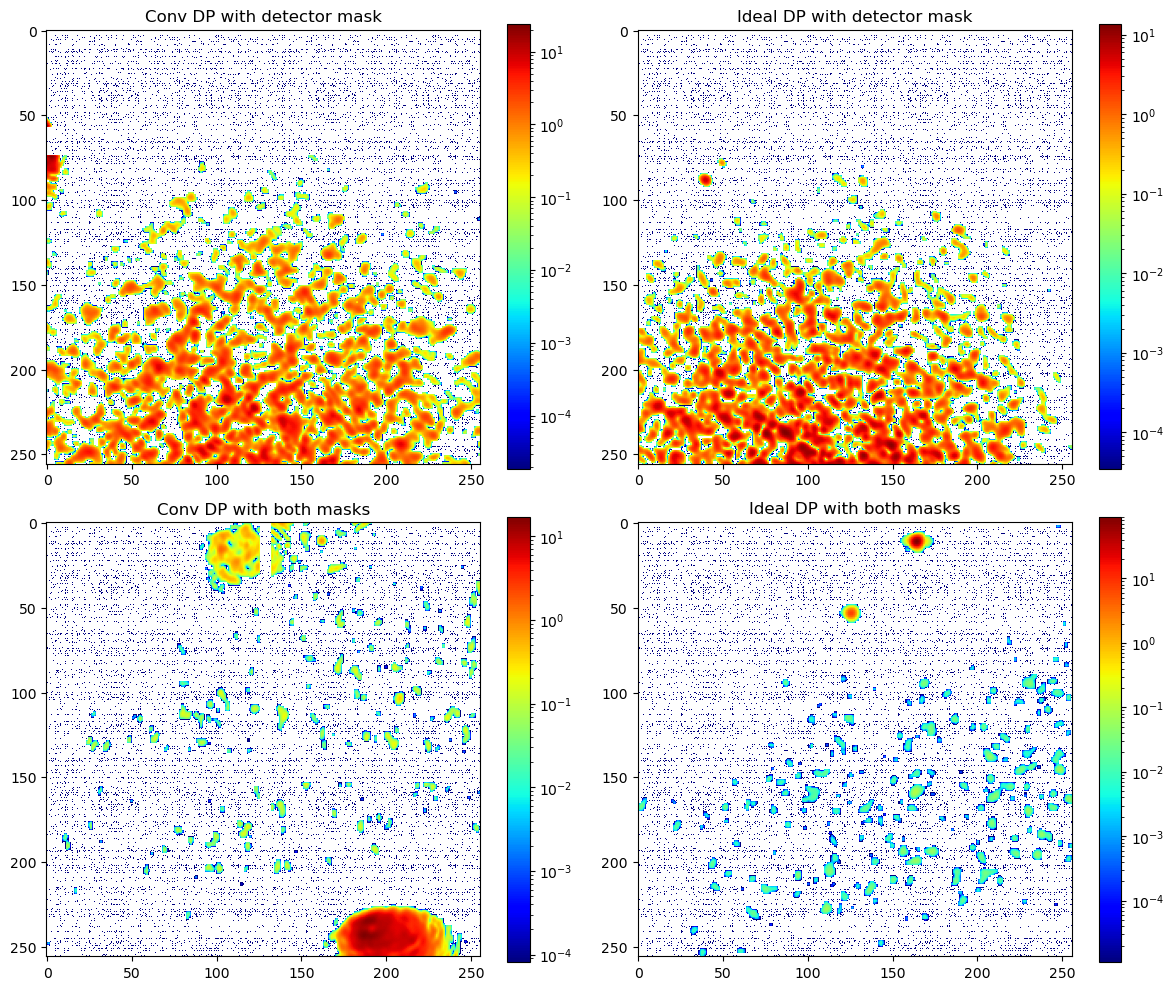

In [89]:
# Visualize the results
ri = np.random.randint(0, len(processed_conv_DPs))
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
print(ri)

# Original images with detector mask
im1 = ax[0, 0].imshow(masked_conv, cmap="jet", norm=colors.LogNorm())
ax[0, 0].set_title("Conv DP with detector mask")
plt.colorbar(im1, ax=ax[0, 0])

im2 = ax[0, 1].imshow(masked_ideal, cmap="jet", norm=colors.LogNorm())
ax[0, 1].set_title("Ideal DP with detector mask")
plt.colorbar(im2, ax=ax[0, 1])

# Images with both masks
im3 = ax[1, 0].imshow(processed_conv_DPs[ri], cmap="jet", norm=colors.LogNorm())
ax[1, 0].set_title("Conv DP with both masks")
plt.colorbar(im3, ax=ax[1, 0])

im4 = ax[1, 1].imshow(processed_ideal_DPs[ri], cmap="jet", norm=colors.LogNorm())
ax[1, 1].set_title("Ideal DP with both masks")
plt.colorbar(im4, ax=ax[1, 1])

plt.tight_layout()
plt.show()

In [36]:
# # Deal with detector mask
# # upper and lower bar bounds for diffraction panels

# # chansong
# # conv_DPs_masked=np.asarray([apply_mask(conv_DPs[i],np.load(os.path.abspath(os.path.join(os.getcwd(), '../../data/mask/mask_Chansong256x256Cropped.npy')))) for i in range(0,len(conv_DPs))])
# # cindy
# # conv_DPs_masked=np.asarray([apply_mask(conv_DPs[i],np.load(os.path.abspath(os.path.join(os.getcwd(), '../../data/mask/mask_CindyPtychoshelvesHDF5preprocessed.npy')))) for i in range(0,len(conv_DPs))])
# # ZCB_9_3D
# conv_DPs_masked=np.asarray([apply_mask(conv_DPs[i],np.load(os.path.abspath(os.path.join(os.getcwd(), '../../data/mask/mask_ZCB_9_3D.npy')))) for i in tqdm(range(0,len(conv_DPs)))])
# ideal_DPs_masked=np.asarray([apply_mask(ideal_DPs[i],np.load(os.path.abspath(os.path.join(os.getcwd(), '../../data/mask/mask_ZCB_9_3D.npy')))) for i in tqdm(range(0,len(conv_DPs)))])


# #create WAXS mask
# h, w = 256,256
# radius = 54#58 #160*2
# waxs_mask = create_circular_waxs_mask2(conv_DPs_masked[0], radius)
# fig,ax=plt.subplots(1,2)
# im1=ax[0].imshow(conv_DPs_masked[0]*waxs_mask,cmap="jet",norm=colors.LogNorm())
# im2=ax[1].imshow(ideal_DPs_masked[0]*waxs_mask,cmap="jet",norm=colors.LogNorm())
# plt.colorbar(im1)
# plt.colorbar(im2)
# plt.title("Masks")
# plt.show()


# conv_DPs_masked=np.asarray([conv_DPs_masked[i]*waxs_mask for i in tqdm(range(0,len(conv_DPs_masked)))])
# ideal_DPs_masked=np.asarray([ideal_DPs_masked[i]*waxs_mask for i in tqdm(range(0,len(ideal_DPs_masked)))])


# with h5py.File('/net/micdata/data2/12IDC/2025_Feb/ptycho/5045/ZCB_9_3D_5045_00004_00032.h5', "r") as h5f:
#     print(h5f['entry']['data']['data'][()].shape)
#     center=(517,575)
#     dp=h5f['entry']['data']['data'][()][center[0]-128:center[0]+128,center[1]-128:center[1]+128]
#     mask = np.where(dp < 0, 0, 1)  # Create binary mask: 0 where dp<=0, 1 elsewhere
    
#     fig,ax=plt.subplots(1,3)
#     im1=ax[0].imshow(dp,norm=colors.LogNorm())
#     im2=ax[1].imshow(mask)  # No need for LogNorm since mask is binary
#     im3=ax[2].imshow(dp*mask,norm=colors.LogNorm())
#     plt.colorbar(im1)
#     plt.colorbar(im2)
#     plt.colorbar(im3)
#     plt.show()


In [90]:
#shuffle data correspondingly
# indices = np.arange(conv_DPs_masked.shape[0])
# np.random.shuffle(indices)
# conv_DPs_shuff = conv_DPs_masked[indices]
# ideal_DPs_shuff = ideal_DPs_masked[indices]
# probe_DPs_shuff=probe_DPs[indices]

indices = np.arange(processed_conv_DPs.shape[0])
np.random.shuffle(indices)
conv_DPs_shuff = processed_conv_DPs[indices]
ideal_DPs_shuff = processed_ideal_DPs[indices]
probe_DPs_shuff=probe_DPs[indices]

In [91]:
# separate amplitude and phase
# thus network used the amplitude of the intensity patterns
amp_conv = log10_custom(conv_DPs_shuff)
amp_ideal = log10_custom(ideal_DPs_shuff)
amp_probe = np.abs(probe_DPs_shuff)
phase_conv = np.angle(conv_DPs_shuff)
phase_ideal = np.angle(ideal_DPs_shuff)
phase_probe = np.angle(probe_DPs_shuff)

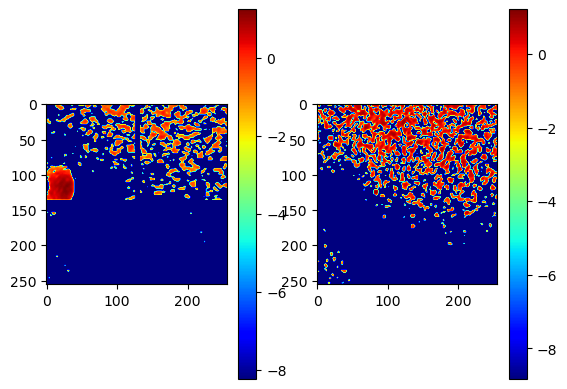

In [94]:
# plot random diffraction pattern
fig,ax=plt.subplots(1,2)
ri=random.randint(0,len(amp_conv))
im1=ax[0].imshow(amp_conv[ri])
im2=ax[1].imshow(amp_ideal[ri])
plt.colorbar(im1)
plt.colorbar(im2)
plt.show()

In [95]:
# resize data
if red:
    print("Resizing...")
    amp_ideal_red=np.asarray([resize(d[:,:],(256,256),preserve_range=True,anti_aliasing=True) for d in tqdm(amp_ideal)])
    amp_conv_red=np.asarray([resize(d[:,:],(256,256),preserve_range=True,anti_aliasing=True) for d in tqdm(amp_conv)])
    amp_probe_red=np.asarray([resize(d[:,:],(256,256),preserve_range=True,anti_aliasing=True) for d in tqdm(amp_probe)])
else:
    print("No resizing...")
    amp_ideal_red=amp_ideal
    amp_conv_red=amp_conv
    amp_probe_red=amp_probe
print(f'maximum in ideal patterns: {np.max(amp_ideal_red[ri])}')
print(f'maximum in conv patterns: {np.max(amp_conv_red[ri])}')    

No resizing...
maximum in ideal patterns: 1.213893398604706
maximum in conv patterns: 1.2443905134949422


/tmp/ipykernel_3318406/2302143922.py:16: RuntimeWarning: invalid value encountered in divide
  amp_probe_red=np.asarray([(a-np.min(a))/(np.max(a)-np.min(a)) for a in amp_probe_red])


normalized maximum in ideal/output patterns: 1.0
normalized maximum in conv/input patterns: 1.0


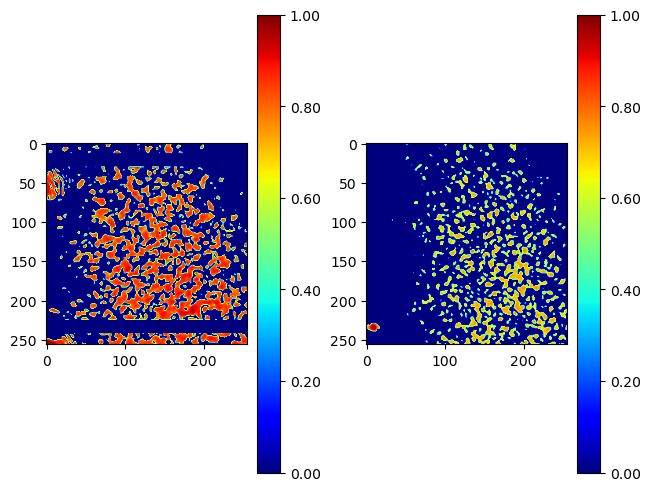

In [96]:
# Scale factors

#NORMALIZE OUTPUT FROM 0 to 1
ideal_scale_factors=np.asarray([(np.max(a)-np.min(a)) for a in amp_ideal_red])
ideal_constants=np.asarray([(np.min(a)) for a in amp_ideal_red])
amp_ideal_red=np.asarray([(a-np.min(a))/(np.max(a)-np.min(a)) for a in amp_ideal_red])

# #NORMALIZE INPUT FROM 0 to 1
conv_scale_factors=np.asarray([(np.max(a)-np.min(a)) for a in amp_conv_red])
conv_constants=np.asarray([(np.min(a)) for a in amp_conv_red])
amp_conv_red=np.asarray([(a-np.min(a))/(np.max(a)-np.min(a)) for a in amp_conv_red])

# #NORMALIZE INPUT FROM 0 to 1
probe_scale_factors=np.asarray([(np.max(a)-np.min(a)) for a in amp_probe_red])
probe_constants=np.asarray([(np.min(a)) for a in amp_probe_red])
amp_probe_red=np.asarray([(a-np.min(a))/(np.max(a)-np.min(a)) for a in amp_probe_red])

print(f'normalized maximum in ideal/output patterns: {np.max(amp_ideal_red[0])}')
print(f'normalized maximum in conv/input patterns: {np.max(amp_conv_red[0])}')

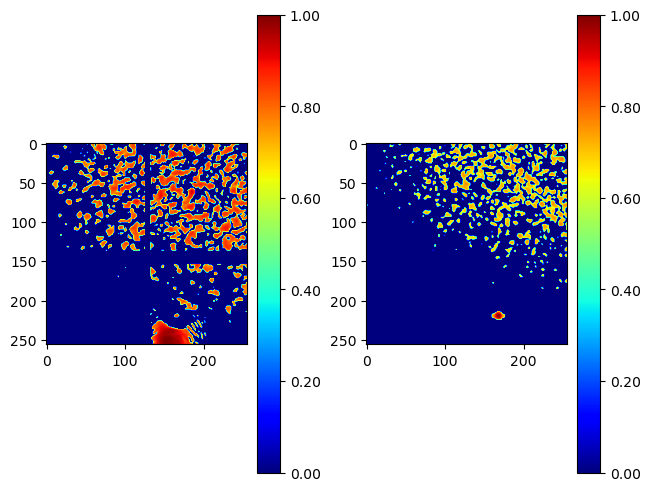

In [106]:
ri=random.randint(0,len(amp_conv_red))
fig,ax=plt.subplots(1,2,layout='constrained')
im1=ax[1].imshow(amp_ideal_red[ri])#,norm=colors.LogNorm())
plt.colorbar(im1, ax=ax[1], format='%.2f')
im2=ax[0].imshow(amp_conv_red[ri])#,norm=colors.LogNorm())
plt.colorbar(im2, ax=ax[0], format='%.2f')
plt.show()

In [100]:
save=True
if save:
    np.savez(os.path.abspath(os.path.join(os.getcwd(), f'../../data/processed/preprocessed_dir{num}_RC02_R3D_numDPs{numDPs}.npz')),amp_conv_red=amp_conv_red,amp_ideal_red=amp_ideal_red,amp_probe_red=amp_probe_red)